### Redes neuronales - Clasificación


In [296]:
#Bloque de imports:

import numpy as np
import pandas as pd
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from keras.utils import to_categorical
from keras.layers import BatchNormalization
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import KFold, train_test_split

plt.rcParams['figure.figsize'] = [3, 3]

In [ ]:
#Bloque de funciones:


# Cargar dataset y dividir en train / test
def cargar_dataset():
    dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
    datos = dataset[:, :512].astype('float32')
    etiquetas = np.array([
        {'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[etiqueta.strip()]
        for etiqueta in dataset[:, 512]
    ])

    trainX, testX, trainY, testY = train_test_split(
        datos,
        etiquetas,
        test_size=0.1,
        random_state=1,
        stratify=etiquetas
    )

    trainY = to_categorical(trainY, num_classes=5)
    testY = to_categorical(testY, num_classes=5)
    return trainX, trainY, testX, testY

# Normalización de tonos de pixel
def prep_pixels(train, test):
    train_norm = train.astype('float32') / 255.0
    test_norm = test.astype('float32') / 255.0
    return train_norm, test_norm

# Agregar estadísticas globales, locales y transiciones de los bytes
def enriquecer_features(datos):
    bytes_originales = np.clip(np.rint(datos * 255), 0, 255).astype('uint8')
    histogramas = np.array([
        np.bincount(fila, minlength=256) / 512.0
        for fila in bytes_originales
    ])
    estadisticas = np.column_stack([
        bytes_originales.mean(axis=1) / 255.0,
        bytes_originales.std(axis=1) / 255.0,
        bytes_originales.min(axis=1) / 255.0,
        bytes_originales.max(axis=1) / 255.0
    ])
    bloques = bytes_originales.reshape(-1, 8, 64)
    histogramas_bloques = np.array([
        np.concatenate([
            np.bincount(bloque, minlength=256) / 64.0
            for bloque in muestra
        ])
        for muestra in bloques
    ])

    # Histograma de pares de bytes cuantizados consecutivos.
    bytes_reducidos = bytes_originales // 16
    transiciones = bytes_reducidos[:, :-1] * 16 + bytes_reducidos[:, 1:]
    histogramas_transiciones = np.array([
        np.bincount(fila, minlength=256) / 511.0
        for fila in transiciones
    ])

    return np.concatenate([
        datos,
        histogramas,
        estadisticas,
        histogramas_bloques,
        histogramas_transiciones
    ], axis=1)


# Graficar un fragmento de bytes
def graficar_uno(valor, conjunto, prediccion=None):
    plt.figure()
    plt.plot(conjunto[valor][:512])
    if prediccion is not None:
        plt.ylabel('Predicho: '+str(prediccion))
    return plt.show()

In [298]:
# Evaluador SIMPLE

def evaluar_modelo_simple(dataX,dataY,modelo,estadoaleatorio=1,epocas=10):
	scores, histories= list(),list()
	model = modelo()
	history = model.fit(trainX, trainY, epochs=epocas, batch_size=32, validation_data=(testX, testY), verbose=1)
	_, acc = model.evaluate(testX, testY, verbose=1)
	print('> %.3f' % (acc * 100.0))
	scores.append(acc)
	histories.append(history)
	return scores, histories, model

# Evaluación con k-fold cross-validation
def evaluar_modelo_kfold(dataX, dataY, modelo, n_folds=5, estadoaleatorio=1):
	scores, histories = list(), list()
	# preparar los k-fold
	kfold = KFold(n_folds, shuffle=True, random_state=estadoaleatorio)
	# Enumerar las divisiones
	for train_ix, test_ix in kfold.split(dataX):
		# definir model
		model = modelo()
		# elegir filas para train y validation
		trainX, trainY, testX, testY = dataX[train_ix], dataY[train_ix], dataX[test_ix], dataY[test_ix]
		# fitear modelo
		history = model.fit(trainX, trainY, epochs=10, batch_size=32, validation_data=(testX, testY), verbose=0)
		# evaluar modelo
		_, acc = model.evaluate(testX, testY, verbose=0)
		print('> %.3f' % (acc * 100.0))
		# guardar puntajes
		scores.append(acc)
		histories.append(history)
	return scores, histories, model

# Graficar diagnósticos
def diagnosticos(histories):
	for i in range(len(histories)):
		# graficar loss
		plt.subplot(2, 1, 1)
		plt.title('Cross Entropy Loss')
		plt.plot(histories[i].history['loss'], color='blue', label='train')
		plt.plot(histories[i].history['val_loss'], color='orange', label='test')
		# graficar accuracy
		plt.subplot(2, 1, 2)
		plt.title('Classification Accuracy')
		plt.plot(histories[i].history['accuracy'], color='blue', label='train')
		plt.plot(histories[i].history['val_accuracy'], color='orange', label='test')
	plt.show()

In [299]:
trainX, trainY, testX, testY = cargar_dataset()
trainX, testX = prep_pixels(trainX, testX)
trainX = enriquecer_features(trainX)
testX = enriquecer_features(testX)
print('Dimensiones trainX:', trainX.shape)
print('Dimensiones testX:', testX.shape)

Dimensiones trainX: (3600, 3076)
Dimensiones testX: (400, 3076)


In [300]:
def cargar_dataset_completo():
    dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
    datos = dataset[:, :512].astype('float32') / 255.0
    etiquetas = np.array([
        {'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[etiqueta.strip()]
        for etiqueta in dataset[:, 512]
    ])
    datos = enriquecer_features(datos)
    etiquetas = to_categorical(etiquetas, num_classes=5)
    return datos, etiquetas


def entrenar_modelo_completo(epocas):
    datos, etiquetas = cargar_dataset_completo()
    modelo_final = definir_modelo()
    modelo_final.fit(
        datos,
        etiquetas,
        epochs=epocas,
        batch_size=32,
        verbose=1
    )
    return modelo_final


def predecirparaunalista(redneuronalentrenada,conjunto=None):
    if conjunto is None:
        conjunto = testX
    puntajes = redneuronalentrenada.predict(conjunto)
    prediccion = np.zeros(len(conjunto), dtype=int)
    for x in range(len(conjunto)):
        prediccion[x] = np.argmax(puntajes[x])
    unique, counts = np.unique(prediccion,return_counts=True)
    return dict(zip(unique,counts))

def matrizdeconfusion(redneuronalentrenada,conjunto=None, targetsonehot=None, normalizar=False):
    if conjunto is None:
        conjunto = testX
    if targetsonehot is None:
        targetsonehot = testY

    puntajes = redneuronalentrenada.predict(conjunto, verbose=0)
    prediccion = np.argmax(puntajes, axis=1)
    objetivo = np.argmax(targetsonehot, axis=1)
    etiquetas = ['gif', 'jpg', 'png', 'qoi', 'webp']

    matriz = confusion_matrix(
        objetivo,
        prediccion,
        normalize='true' if normalizar else None
    )
    display = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=etiquetas
    )
    display.plot(cmap='Blues', values_format='.2f' if normalizar else 'd')
    plt.title('Matriz de confusión')
    plt.show()


def find_non_equal_indices(list1, list2):
    non_equal_indices = []
    for i in range(min(len(list1), len(list2))):
        if list1[i] != list2[i]:
            non_equal_indices.append(i)
    return non_equal_indices

def listarerrores(adivinado,objetivo=testY):
    errores = find_non_equal_indices(adivinado,np.argmax(objetivo, axis = 1))
    return errores

In [301]:
print ("Tamaño de conjunto de entrenamiento: "+str(len(trainX)) + "\n"+"Tamaño de conjunto de test:          "+str(len(testX)))

Tamaño de conjunto de entrenamiento: 3600
Tamaño de conjunto de test:          400


In [302]:
plt.rcParams['figure.figsize'] = [3, 3]

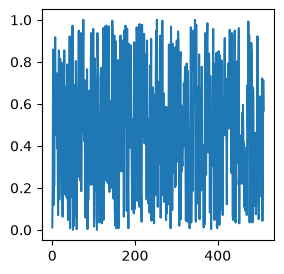

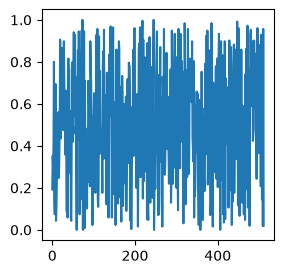

In [303]:
graficar_uno(315, trainX)
graficar_uno(100, testX)

In [ ]:
# Modelo feedforward para clasificación

def definir_modelo():
    modelo = Sequential([
        keras.Input(shape=(3076,)),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(5, activation='softmax')
    ])

    modelo.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return modelo

Epoch 1/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4986 - loss: 1.3572 - val_accuracy: 0.2125 - val_loss: 2.2500 - learning_rate: 0.0010
Epoch 2/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6808 - loss: 0.8718 - val_accuracy: 0.5325 - val_loss: 1.0908 - learning_rate: 0.0010
Epoch 3/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7606 - loss: 0.7351 - val_accuracy: 0.6200 - val_loss: 0.9344 - learning_rate: 0.0010
Epoch 4/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8200 - loss: 0.6444 - val_accuracy: 0.5800 - val_loss: 1.3850 - learning_rate: 0.0010
Epoch 5/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8511 - loss: 0.5771 - val_accuracy: 0.6550 - val_loss: 0.9421 - learning_rate: 0.0010
Epoch 6/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8872 - loss: 0.5210 - val_accuracy: 0.7075 - val_loss: 0.8354 - learning_rate: 0.0010
Epoch 7/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9061 - loss: 0.

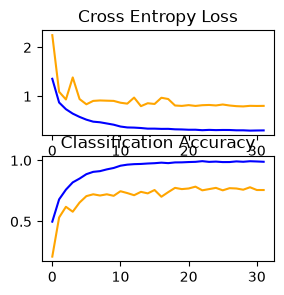

In [305]:
modelo_entrenado = definir_modelo()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=0.00001
)

# Entrenamiento y evaluación del modelo base
history = modelo_entrenado.fit(
    trainX,
    trainY,
    epochs=150,
    batch_size=32,
    validation_data=(testX, testY),
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

loss, accuracy = modelo_entrenado.evaluate(testX, testY, verbose=0)
print(f'Accuracy de validación: {accuracy * 100:.2f}%')
print("Épocas ejecutadas:", len(history.history["loss"]))
print("Mejor época por val_loss:", np.argmin(history.history["val_loss"]) + 1)
print("Mejor época por val_accuracy:", np.argmax(history.history["val_accuracy"]) + 1)

diagnosticos([history])

In [306]:
# Evaluación en test_publico.csv
publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publicoX = publico[:, :512].astype('float32') / 255.0
publicoX = enriquecer_features(publicoX)
publicoY = np.array([
    {'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[etiqueta.strip()]
    for etiqueta in publico[:, 512]
])
publicoY = to_categorical(publicoY, num_classes=5)

publico_loss, publico_accuracy = modelo_entrenado.evaluate(
    publicoX,
    publicoY,
    verbose=0
)
print(f'Accuracy en test_publico: {publico_accuracy * 100:.2f}%')

print("Mejor train:", max(history.history["accuracy"]) * 100)
print("Mejor validación:", max(history.history["val_accuracy"]) * 100)
print("Test público:", publico_accuracy * 100)

Accuracy en test_publico: 69.20%
Mejor train: 99.36110973358154
Mejor validación: 78.50000262260437
Test público: 69.19999718666077


In [307]:
# Entrenamiento final con las 4000 muestras etiquetadas
epocas_finales = np.argmax(history.history['val_accuracy']) + 1
modelo_final = entrenar_modelo_completo(epocas_finales)

final_publico_loss, final_publico_accuracy = modelo_final.evaluate(
    publicoX,
    publicoY,
    verbose=0
)
print(f'Accuracy del modelo final en test_publico: {final_publico_accuracy * 100:.2f}%')

Epoch 1/22
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4975 - loss: 1.3637
Epoch 2/22
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6637 - loss: 0.9012
Epoch 3/22
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7498 - loss: 0.7552
Epoch 4/22
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7977 - loss: 0.6745
Epoch 5/22
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8415 - loss: 0.6043
Epoch 6/22
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8763 - loss: 0.5469
Epoch 7/22
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8917 - loss: 0.5064
Epoch 8/22
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9145 - loss: 0.4681
Epoch 9/22
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9212 - loss: 0.4468
Epoch 10/22
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9310 - loss: 0.4320
Epoch 11/22
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9425 - loss: 0.4116
Epoch 12/22
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

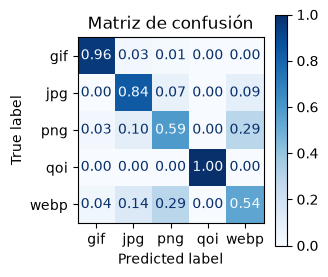

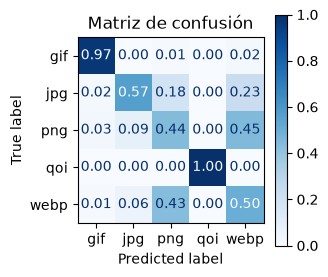

In [308]:
# Matriz de confusión sobre el conjunto de validación
matrizdeconfusion(modelo_entrenado, testX, testY, normalizar=True)

matrizdeconfusion(modelo_entrenado, publicoX,publicoY, normalizar=True)



In [ ]:
# Cargar el conjunto final sin etiquetas
test_features = np.loadtxt(
    '../dataset/clasificacion_test_features.csv',
    delimiter=',',
    dtype='float32'
) / 255.0
test_features = enriquecer_features(test_features)

print('Dimensiones de test_features:', test_features.shape)

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']

probas = modelo_entrenado.predict(test_features)
predicciones = [clases[i] for i in np.argmax(probas, axis=1)]

pd.DataFrame({
    'y_pred': predicciones
}).to_csv('entrega_clasificacion.csv', index=False)

Dimensiones de test_features: (500, 512)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step
